# Bidirectional LSTM Model for Named Entity Recognition (NER) trained on CoNLL-2003 Dataset

### Register Numeber: 23BAI1589 - Yashvanth Karunakaran

### AIM:
To Design and implement a Bidirectional LSTM model for Named Entity
Recognition (NER) using the CoNLL-2003 dataset. The model should classify
each word in a sentence into one of nine entity categories (e.g., person,
organization, location) or "non-entity."

### 1. Data Preparation

In [ ]:
!pip install seqeval tensorflow matplotlib datasets numpy

#### Loading dataset

In [1]:
from datasets import load_dataset

df=load_dataset("conll2003",revision="refs/convert/parquet")

df

/media/yashix/New Volume/Speech/Lab/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

#### Target Label NER Tags

In [2]:
label_names=df['train'].features['ner_tags'].feature.names
label_names

#### Creating label to index and index to label mapping

In [3]:
label2idx={label:i for i,label in enumerate(label_names)}
idx2label={i:label for label,i in label2idx.items()}

#### Splitting train, validation and test sentences and labels

In [4]:
train_sentences=df['train']['tokens']
train_labels=df['train']['ner_tags']

val_sentences=df['validation']['tokens']
val_labels=df['validation']['ner_tags']

test_sentences=df['test']['tokens']
test_labels=df['test']['ner_tags']

#### Exploring training sentence

In [5]:
train_sentences[0]

['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']

#### Exploring training sentence labels

In [6]:
train_labels[0]

[3, 0, 7, 0, 0, 0, 7, 0, 0]

#### Converting the label indices to NER tags

In [7]:
[idx2label[i] for i in train_labels[0]]

['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']

#### Preparing Vocabulary

In [8]:
vocab=set()
for sentence in train_sentences:
    vocab.update(sentence)
print("Vocabulary Size:",len(vocab))

Vocabulary Size: 23623


#### Creating word to index and index to word mapping

In [9]:
word2idx={'<PAD>':0,'<UNK>':1}
for i,word in enumerate(sorted(vocab),start=2):
    word2idx[word]=i
idx2word={i:word for word,i in word2idx.items()}

list(word2idx.keys())[:10]

['<PAD>', '<UNK>', '!', '"', '$', '%', '&', "'", "'S", "'d"]

#### Converting train, validation and test sentences to indices

In [10]:
def sentences_to_idx(sentences):
    result=[]
    for sentence in sentences:
        sent=[]
        for word in sentence:
            if word in word2idx:
                sent.append(word2idx[word])
            else:
                sent.append(word2idx['<UNK>'])
        result.append(sent)
    return result

train_sentence_idx=sentences_to_idx(train_sentences)
val_sentence_idx=sentences_to_idx(val_sentences)
test_sentence_idx=sentences_to_idx(test_sentences)

#### Exploring training sentence mapped to index

In [11]:
train_sentence_idx[0]

[6420, 20821, 7229, 14822, 22700, 14673, 5084, 18390, 125]

#### Padding sentences to fixed length of 100
exploring the padded training sentence

In [14]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN=100

X_train=pad_sequences(train_sentence_idx,maxlen=MAX_LEN,padding='post',truncating='post',value=word2idx['<PAD>'])
X_val=pad_sequences(val_sentence_idx,maxlen=MAX_LEN,padding='post',truncating='post',value=word2idx['<PAD>'])
X_test=pad_sequences(test_sentence_idx,maxlen=MAX_LEN,padding='post',truncating='post',value=word2idx['<PAD>'])

y_train=pad_sequences(train_labels,maxlen=MAX_LEN,padding='post',value=0)
y_val=pad_sequences(val_labels,maxlen=MAX_LEN,padding='post',value=0)
y_test=pad_sequences(test_labels,maxlen=MAX_LEN,padding='post',value=0)

X_train[0]

2026-02-16 20:55:45.201008: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-16 20:55:45.241166: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 20:55:47.801428: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


array([ 6420, 20821,  7229, 14822, 22700, 14673,  5084, 18390,   125,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0], dtype=int32)

#### Checking the padding label for sentence

In [15]:
y_train[0]

array([3, 0, 7, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

### 2. Model Architecture

Deep Bidirectional LSTM architecture for Named Entity Recognition (NER). Embedding layer converts input tokens into 100-dimensional dense vector (using masking to ignore padded positions). Dropout layer improve generalization and reduce overfitting. Two stacked Bidirectional LSTM layers, the first with 128 units to capture rich contextual dependencies from both forward and backward directions, and the second with 64 units for refining sequential patterns further. TimeDistributed dense layer with a softmax activation function produces probability distributions over the label set

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Bidirectional,LSTM,TimeDistributed,Dense,Dropout,Input

VOCAB_SIZE=len(word2idx)
EMBEDDING_DIM=100
NUM_LABELS=len(label2idx)
LSTM_UNITS=128
DROPOUT_RATE=0.3

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, 
              output_dim=EMBEDDING_DIM, 
              input_length=MAX_LEN,
              mask_zero=True),
    Dropout(DROPOUT_RATE),
    Bidirectional(LSTM(units=LSTM_UNITS, 
                      return_sequences=True,
                      recurrent_dropout=0.1)),
    Dropout(DROPOUT_RATE),
    Bidirectional(LSTM(units=LSTM_UNITS//2, 
                      return_sequences=True,
                      recurrent_dropout=0.1)),
    TimeDistributed(Dense(NUM_LABELS, activation='softmax'))
])

model.summary()

/media/yashix/New Volume/Speech/Lab/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1771255550.352330   30244 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1771255550.363928   30244 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     2,362,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 9)         │         1,161 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,762,509 (10.54 MB)

 Trainable params: 2,762,509 (10.54 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Compiling

In [17]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

#### Model Training
batch size of 32 for up to 10 epochs, using 20% of the data for validation. EarlyStopping prevents overfitting by stopping training when validation loss stops improving and restores the best weights. ReduceLROnPlateau lowers the learning rate when performance plateaus

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

BATCH_SIZE=32
EPOCHS=10

callbacks=[
    EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2,min_lr=1e-6,verbose=1)
]

history=model.fit(X_train,y_train,batch_size=BATCH_SIZE,epochs=EPOCHS,validation_data=(X_val,y_val),callbacks=callbacks)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 97s 200ms/step - accuracy: 0.8597 - loss: 0.5504 - val_accuracy: 0.9020 - val_loss: 0.3353 - learning_rate: 0.0010
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 82s 187ms/step - accuracy: 0.9394 - loss: 0.1895 - val_accuracy: 0.9373 - val_loss: 0.2233 - learning_rate: 0.0010
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 80s 182ms/step - accuracy: 0.9725 - loss: 0.0953 - val_accuracy: 0.9378 - val_loss: 0.2105 - learning_rate: 0.0010
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 78s 177ms/step - accuracy: 0.9848 - loss: 0.0548 - val_accuracy: 0.9488 - val_loss: 0.1840 - learning_rate: 0.0010
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 78s 179ms/step - accuracy: 0.9905 - loss: 0.0360 - val_accuracy: 0.9404 - val_loss: 0.2077 - learning_rate: 0.0010
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 84s 190ms/step - accuracy: 0.9927 - loss: 0.0270 - val_accuracy: 0.9519 - val_loss: 0.1838 - learning_rate: 0.0010
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 80s 181ms/step - accuracy: 0.9

#### Model Evaluation
Visualization plots the model’s training and validation performance across epochs

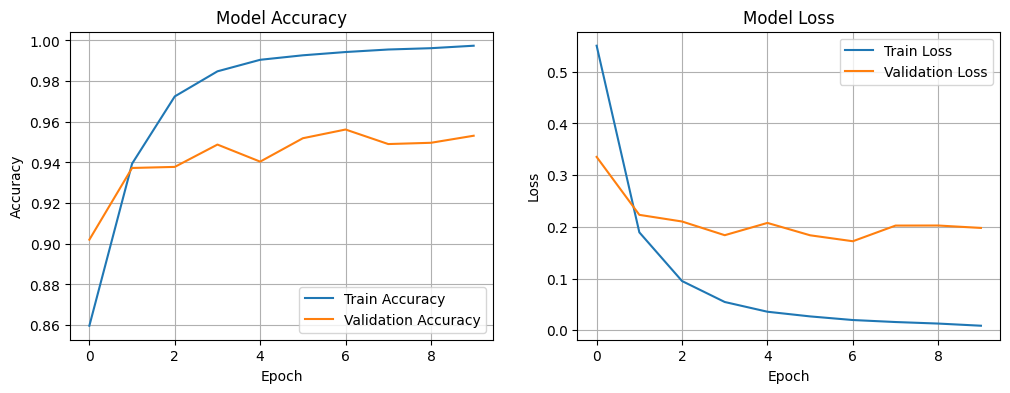

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

#### Model Prediction Exploration

Generates predictions on the test dataset using the trained model with the specified batch size

In [20]:
y_pred=model.predict(X_test,batch_size=BATCH_SIZE)

108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step


#### Exploring test sentence

In [21]:
X_test[0]

array([11591,   114,     1,     1,     1, 13274,   113,  5245,  7919,
           1,  5975,   125,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0], dtype=int32)

#### Checking for actual words in the test sentence

In [22]:
import numpy as np

np.array([idx2word[i] for i in X_test[0]])

array(['SOCCER', '-', '<UNK>', '<UNK>', '<UNK>', 'WIN', ',', 'CHINA',
       'IN', '<UNK>', 'DEFEAT', '.', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>',
       '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>'],
      dtype='<U6

#### Prediction distribution for first word in the sentence

In [23]:
y_pred[0][0]

array([9.9997014e-01, 3.1257036e-06, 1.8000911e-07, 2.0654263e-06,
       5.2152550e-06, 1.2169558e-06, 1.8509734e-06, 8.7576291e-06,
       7.4012460e-06], dtype=float32)

#### First test sentence label prediction

In [24]:
y_pred_0_label_idx=np.array([int(np.argmax(labels)) for labels in y_pred[0]])
y_pred_0_label_idx

array([0, 0, 0, 1, 2, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

#### Converting the indices back to actual labels

In [25]:
np.array([idx2label[i] for i in y_pred_0_label_idx])

array(['O', 'O', 'O', 'B-PER', 'I-PER', 'O', 'O', 'B-ORG', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'], dtype='<U5')

#### Checking for actual test target labels

In [26]:
y_test[0]

array([0, 0, 5, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

#### Getting actual predicted labels by taking maximum over the probability distribution

In [27]:
y_pred_classes=np.argmax(y_pred,axis=-1)

#### Model evaluation

In [28]:
test_loss,test_accuracy=model.evaluate(X_test,y_test,batch_size=BATCH_SIZE)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9305 - loss: 0.2829
Test Loss: 0.28294679522514343
Test Accuracy: 0.9304905533790588


#### Getting actual target and predicted labels for each sentence in test set

In [29]:
y_tags=[]
y_pred_tags=[]

for i in range(len(y_test)):
    true_seq=[]
    pred_seq=[]
    for j in range(len(y_test[i])):
        if X_test[i][j]!=word2idx['<PAD>']:
            true_seq.append(idx2label[y_test[i][j]])
            pred_seq.append(idx2label[y_pred_classes[i][j]])
    if true_seq:
        y_tags.append(true_seq)
        y_pred_tags.append(pred_seq)
    
print("Total Test Sequences:",len(y_tags))

Total Test Sequences: 3453


#### Evaluation metrics
calculating F1-score

In [30]:
from seqeval.metrics import classification_report, f1_score

f1 = f1_score(y_tags, y_pred_tags)
print(f"F1 Score: {f1:.2f}")

F1 Score: 0.69


Generating classification report

In [31]:
print(classification_report(y_tags,y_pred_tags))

              precision    recall  f1-score   support

         LOC       0.75      0.68      0.71      1665
        MISC       0.48      0.64      0.55       702
         ORG       0.73      0.68      0.70      1660
         PER       0.65      0.80      0.71      1614

   micro avg       0.67      0.71      0.69      5641
   macro avg       0.65      0.70      0.67      5641
weighted avg       0.68      0.71      0.69      5641



#### Predicting the tags for a sample sentence

In [32]:
def predict_ner_sentence(model,text):
    tokens = text.split()
    token_ids = [word2idx.get(word, word2idx['<UNK>']) for word in tokens]
    padded_ids = pad_sequences([token_ids], maxlen=MAX_LEN, padding='post', value=word2idx['<PAD>'])

    pred_probs = model.predict(padded_ids, verbose=0)
    pred_ids = np.argmax(pred_probs, axis=-1)[0]
    pred_labels = [idx2label[i] for i in pred_ids[:len(tokens)]]

    print("NER Predictions:")
    for word, label in zip(tokens, pred_labels):
        print(f"{word}: {label}")

predict_ner_sentence(model,"Apple launched iPhone in California")

NER Predictions:
Apple: B-ORG
launched: O
iPhone: B-PER
in: O
California: B-LOC


### Hyperparameter Tuning

#### Model with a deeper and more regularized Bidirectional LSTM architecture for sequence labeling
200-dimensional embedding layer enhanced with L2 regularization and masking support, followed by SpatialDropout1D. Three stacked Bidirectional LSTM layers. Additional dropout layers. TimeDistributed dense layer with ReLU activation. TimeDistributed softmax layer produces token-wise class probabilities

In [33]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import SpatialDropout1D
from tensorflow.keras.models import Model

VOCAB_SIZE = len(word2idx)
EMBEDDING_DIM = 200
LSTM_UNITS = 256
NUM_LABELS = len(label2idx)

inputs = Input(shape=(MAX_LEN,), dtype='int32')

x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN,
    mask_zero=True,
    embeddings_regularizer=l2(1e-4)
)(inputs)

x = SpatialDropout1D(0.15)(x)

x = Bidirectional(LSTM(
    units=128,
    return_sequences=True,
    recurrent_dropout=0.2,
    kernel_regularizer=l2(1e-4)
))(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(
    units=128,
    return_sequences=True,
    recurrent_dropout=0.2,
    kernel_regularizer=l2(1e-4)
))(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(
    units=128,
    return_sequences=True,
    recurrent_dropout=0.2
))(x)
x = Dropout(0.3)(x)

x = TimeDistributed(Dense(128, activation='relu'))(x)
x = Dropout(0.3)(x)

outputs = TimeDistributed(Dense(NUM_LABELS, activation='softmax'))(x)

model1 = Model(inputs=inputs, outputs=outputs)

model1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 200)  │  4,725,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 100, 200)  │          0 │ embedding_1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 100)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 100, 256)  │    336,896 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 100, 256)  │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 100, 256)  │    394,240 │ dropout_2[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 100, 256)  │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 100, 256)  │    394,240 │ dropout_3[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 100, 256)  │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 100, 128)  │     32,896 │ dropout_4[0][0],  │
│ (TimeDistributed)   │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 100, 128)  │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 100, 9)    │      1,161 │ dropout_5[0][0],  │
│ (TimeDistributed)   │                   │            │ not_equal_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,884,433 (22.45 MB)

 Trainable params: 5,884,433 (22.45 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Compiling

In [34]:
model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Model training

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
    ),
    ModelCheckpoint(
        'best_ner_model.h5',
        monitor='val_loss',
        save_best_only=True,
    )
]

In [36]:
history1 = model1.fit(
    X_train, y_train,
    batch_size=64,
    epochs=8,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.8089 - loss: 1.1296

220/220 ━━━━━━━━━━━━━━━━━━━━ 183s 765ms/step - accuracy: 0.8294 - loss: 0.8343 - val_accuracy: 0.8596 - val_loss: 0.5721 - learning_rate: 0.0010
Epoch 2/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.8814 - loss: 0.4158

220/220 ━━━━━━━━━━━━━━━━━━━━ 162s 738ms/step - accuracy: 0.8947 - loss: 0.3791 - val_accuracy: 0.9120 - val_loss: 0.3642 - learning_rate: 0.0010
Epoch 3/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.9323 - loss: 0.2790

220/220 ━━━━━━━━━━━━━━━━━━━━ 167s 758ms/step - accuracy: 0.9390 - loss: 0.2630 - val_accuracy: 0.9402 - val_loss: 0.3037 - learning_rate: 0.0010
Epoch 4/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.9624 - loss: 0.2057

220/220 ━━━━━━━━━━━━━━━━━━━━ 157s 715ms/step - accuracy: 0.9653 - loss: 0.1994 - val_accuracy: 0.9527 - val_loss: 0.2710 - learning_rate: 0.0010
Epoch 5/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.9783 - loss: 0.1604

220/220 ━━━━━━━━━━━━━━━━━━━━ 152s 689ms/step - accuracy: 0.9778 - loss: 0.1615 - val_accuracy: 0.9568 - val_loss: 0.2703 - learning_rate: 0.0010
Epoch 6/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.9841 - loss: 0.1388

220/220 ━━━━━━━━━━━━━━━━━━━━ 148s 675ms/step - accuracy: 0.9832 - loss: 0.1385 - val_accuracy: 0.9581 - val_loss: 0.2455 - learning_rate: 0.0010
Epoch 7/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.9864 - loss: 0.1259

220/220 ━━━━━━━━━━━━━━━━━━━━ 154s 701ms/step - accuracy: 0.9860 - loss: 0.1271 - val_accuracy: 0.9598 - val_loss: 0.2417 - learning_rate: 0.0010
Epoch 8/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 150s 682ms/step - accuracy: 0.9879 - loss: 0.1176 - val_accuracy: 0.9577 - val_loss: 0.2504 - learning_rate: 0.0010


#### Model evaluation

In [37]:
test_loss,test_accuracy=model1.evaluate(X_test,y_test,batch_size=64)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.9433 - loss: 0.3333
Test Loss: 0.3333435356616974
Test Accuracy: 0.9432679414749146


#### Plotting the model’s training and validation performance across epochs.

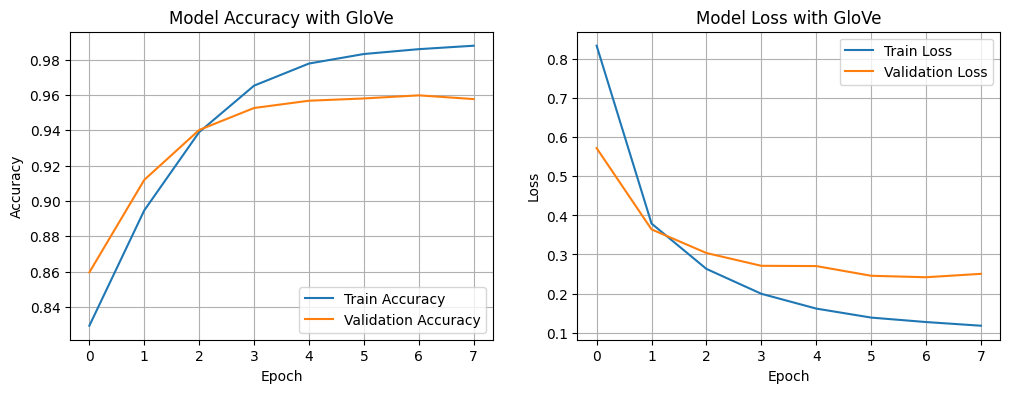

In [38]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'],label='Train Accuracy')
plt.plot(history1.history['val_accuracy'],label='Validation Accuracy')
plt.title("Model Accuracy with GloVe")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history1.history['loss'],label='Train Loss')
plt.plot(history1.history['val_loss'],label='Validation Loss')
plt.title("Model Loss with GloVe")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

#### Generating target and predicted labels and calculating F1-score

In [39]:
y_pred=model1.predict(X_test,batch_size=BATCH_SIZE)
y_pred_classes=np.argmax(y_pred,axis=-1)

y_tags=[]
y_pred_tags=[]

for i in range(len(y_test)):
    true_seq=[]
    pred_seq=[]
    for j in range(len(y_test[i])):
        if X_test[i][j]!=word2idx['<PAD>']:
            true_seq.append(idx2label[y_test[i][j]])
            pred_seq.append(idx2label[y_pred_classes[i][j]])
    if true_seq:
        y_tags.append(true_seq)
        y_pred_tags.append(pred_seq)
    
f1 = f1_score(y_tags, y_pred_tags)
print(f"F1 Score: {f1:.2f}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step
F1 Score: 0.72


#### Generating classification report

In [40]:
print(classification_report(y_tags,y_pred_tags))

              precision    recall  f1-score   support

         LOC       0.82      0.77      0.80      1665
        MISC       0.66      0.61      0.63       702
         ORG       0.72      0.60      0.66      1660
         PER       0.75      0.72      0.73      1614

   micro avg       0.75      0.69      0.72      5641
   macro avg       0.74      0.68      0.71      5641
weighted avg       0.75      0.69      0.72      5641



#### Predicting the sentence

In [41]:
predict_ner_sentence(model1,"Apple launched iPhone in California")

NER Predictions:
Apple: B-LOC
launched: O
iPhone: O
in: O
California: B-LOC


### Glove Embedding

#### Downloading the GloVe Embedding

In [42]:
import urllib.request
import zipfile
import os

GLOVE_URL="http://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_FILE="glove.6B.100d.txt"

if not os.path.exists(GLOVE_FILE):
    urllib.request.urlretrieve(GLOVE_URL,"glove.6B.zip")
    with zipfile.ZipFile("glove.6B.zip","r") as zip_ref:
        zip_ref.extractall(".")
else:
    print(f"{GLOVE_FILE} already exists")

glove.6B.100d.txt already exists


creates a zero matrix of shape (vocabulary size × 100 dimensions) and then reads the GloVe file line by line. 

In [ ]:
embedding_dim = 100
embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))

with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        if word in word2idx:
            embedding_matrix[word2idx[word]] = vector

#### GloVe-Enhanced Bidirectional LSTM for Robust Sequence Tagging

In [44]:
model_glove=Sequential([
    Input(shape=(MAX_LEN,)),
    
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True,
        mask_zero=True
    ),
    Dropout(0.5),

    Bidirectional(LSTM(128, return_sequences=True, dropout=0.5, recurrent_dropout=0.5)),
    Dropout(0.5),

    Bidirectional(LSTM(128, return_sequences=True, dropout=0.5, recurrent_dropout=0.5)),
    Dropout(0.5),

    TimeDistributed(Dense(64, activation="relu")),
    TimeDistributed(Dense(NUM_LABELS, activation="softmax"))
])

model_glove.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 100)       │     2,362,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 100, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 100, 256)       │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 100, 64)        │        16,448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 100, 9)         │           585 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,008,269 (11.48 MB)

 Trainable params: 3,008,269 (11.48 MB)

 Non-trainable params: 0 (0.00 B)

#### Model compiling

In [45]:
model_glove.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#### Model Training

In [46]:
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
    )
]

history_glove  = model_glove.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 147s 306ms/step - accuracy: 0.8494 - loss: 0.5091 - val_accuracy: 0.8732 - val_loss: 0.3809 - learning_rate: 0.0010
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 142s 323ms/step - accuracy: 0.9083 - loss: 0.2686 - val_accuracy: 0.9031 - val_loss: 0.2838 - learning_rate: 0.0010
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 140s 320ms/step - accuracy: 0.9415 - loss: 0.1790 - val_accuracy: 0.9259 - val_loss: 0.2221 - learning_rate: 0.0010
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 135s 308ms/step - accuracy: 0.9644 - loss: 0.1169 - val_accuracy: 0.9281 - val_loss: 0.2063 - learning_rate: 0.0010
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 143s 325ms/step - accuracy: 0.9755 - loss: 0.0830 - val_accuracy: 0.9309 - val_loss: 0.2070 - learning_rate: 0.0010
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 152s 346ms/step - accuracy: 0.9815 - loss: 0.0652 - val_accuracy: 0.9292 - val_loss: 0.2016 - learning_rate: 0.0010
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 145s 330ms/step - accura

#### Plotting training and validation accuracy and loss over epochs

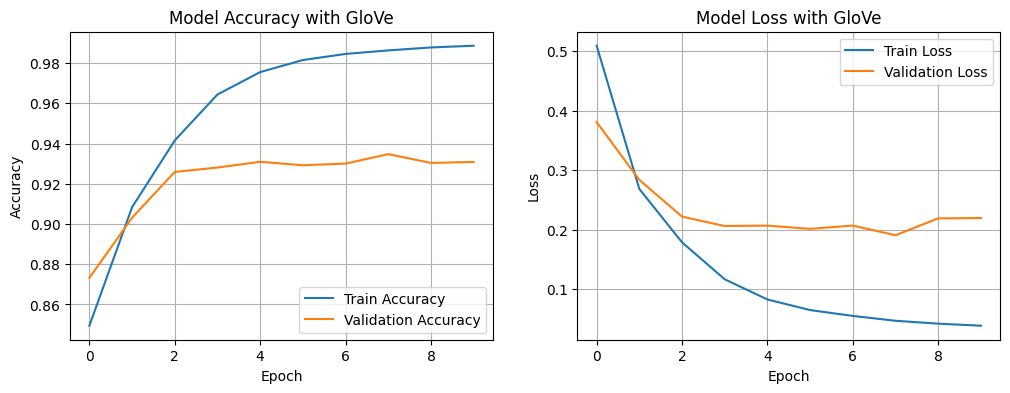

In [47]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_glove.history['accuracy'],label='Train Accuracy')
plt.plot(history_glove.history['val_accuracy'],label='Validation Accuracy')
plt.title("Model Accuracy with GloVe")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history_glove.history['loss'],label='Train Loss')
plt.plot(history_glove.history['val_loss'],label='Validation Loss')
plt.title("Model Loss with GloVe")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

#### Generating target and prediction labels and calculation f1 score and printing classification report

In [48]:
y_pred=model_glove.predict(X_test)
y_pred_classes=np.argmax(y_pred,axis=-1)

y_tags=[]
y_pred_tags=[]

for i in range(len(y_test)):
    true_seq=[]
    pred_seq=[]
    for j in range(len(y_test[i])):
        if X_test[i][j]!=word2idx['<PAD>']:
            true_seq.append(idx2label[y_test[i][j]])
            pred_seq.append(idx2label[y_pred_classes[i][j]])
    if true_seq:
        y_tags.append(true_seq)
        y_pred_tags.append(pred_seq)
    
f1 = f1_score(y_tags, y_pred_tags)
print(f"F1 Score: {f1:.2f}")
print(classification_report(y_tags,y_pred_tags))

108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step
F1 Score: 0.63
              precision    recall  f1-score   support

         LOC       0.73      0.68      0.71      1665
        MISC       0.46      0.62      0.53       702
         ORG       0.41      0.79      0.54      1660
         PER       0.69      0.75      0.72      1614

   micro avg       0.55      0.73      0.63      5641
   macro avg       0.57      0.71      0.62      5641
weighted avg       0.59      0.73      0.64      5641



#### Predicting a sample sentence with GloVe Enhanced model

In [49]:
predict_ner_sentence(model_glove,"Apple launched iPhone in California")

NER Predictions:
Apple: B-ORG
launched: O
iPhone: B-ORG
in: O
California: B-LOC


### F1 Score for different Models
#### Baseline Model: 0.69
#### Hyperparameter tuned model: 0.72
#### GloVe embedded model: 0.63